# Pipeline de Preparación de Datos Robusto

Este notebook implementa el proceso completo de limpieza y generación de características utilizando las funciones modularizadas en `src`. 

**Mejoras incluidas:**
1. Eliminación de categorías ruidosas (`Leisure, Vacations` e `Invoice`).
2. Creación de Lags (1, 2, 3, 12 meses).
3. Estadísticas rodantes (Media y Desviación Estándar).
4. Variables dummy para eventos (Navidad, Verano).
5. Ratios financieros (Ahorro).

In [77]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


# Ajustar el directorio de trabajo a la raíz del proyecto si estamos en /notebooks
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src.data.loader import load_raw_data, load_train_test_data, split_target
from src.features.builder import add_features
from src.models.trainer import train_sklearn_model, train_arima_model, train_sarimax_model, train_lstm_model, train_voting_ensemble, save_model
from src.evaluation.metrics import evaluate_predictions, evaluate_arima, evaluate_sarimax_wfv, evaluate_lstm


print(f"Directorio actual: {os.getcwd()}")

Directorio actual: c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P1_Ap-IA


## 1. Carga y Preprocesamiento Base
Aquí llamamos a `preprocess_data` que ahora incluye el filtrado de categorías ruidosas.

In [78]:
def train_val_test_split(df: pd.DataFrame, dataset_name: str, test_size: float = 0.3, val_size: float = 0.5, verbose: bool = False) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Divide un DataFrame en train, validation y test guardándolos en data/processed.
    """
    # 1. Dividir datos (manteniendo orden temporal si es necesario)
    train_df, temp_df = train_test_split(df, test_size=test_size, shuffle=False)
    if val_size > 0:
        val_df, test_df = train_test_split(temp_df, test_size=val_size, shuffle=False)
    else:
        val_df = pd.DataFrame()
        test_df = temp_df
    
    if verbose:
        print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    
    return train_df, val_df, test_df

def preprocess_data(df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
    # 1. Convertimos 'Date' a datetime
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    
    # 2. 'Amount' viene como string con coma, € y punto. Lo pasamos a float
    # Verificamos si es tipo objeto (string en pandas)
    if df['Amount'].dtype == 'str':
        df['Amount'] = df['Amount'].astype(str).str.replace('€', '', regex=False)
        df['Amount'] = df['Amount'].str.replace('.', '', regex=False)
        df['Amount'] = df['Amount'].str.replace(',', '.', regex=False).astype(float)

    # 3. Eliminar Outliers / Ruido (según cuaderno de pruebas)
    outlier_categories = ['Leisure, Vacations', 'Invoice']
    df = df[~df['Area'].isin(outlier_categories)].copy()

    # 4. Convertir los gastos ('Expenses') en valores negativos
    if 'Type' in df.columns:
        df.loc[df['Type'] == 'Expenses', 'Amount'] = -df.loc[df['Type'] == 'Expenses', 'Amount'].abs()

    # 5. Normalizar Nombres de Área (Codificación corta)
    def get_code(name):
        words = str(name).replace(",", "").split()
        return "".join([w[:2].capitalize() for w in words])

    if verbose:
        mapping = ", ".join([f"{a} -> {get_code(a)}" for a in df['Area'].unique()])
        print(f"Mapeo de áreas: {mapping}")

    df['Area'] = df['Area'].apply(get_code)

    return df


In [79]:
df_raw = load_raw_data("db_orig")
print(f"Filas originales: {len(df_raw)}")

Filas originales: 885


In [ ]:
df_clean = preprocess_data(df_raw, verbose=True)
print(f"Filas tras limpieza de outliers: {len(df_clean)}")

Mapeo de áreas: Leisure -> Le, Salary -> Sa, Food -> Fo, Investment -> In, Deposit -> De, Food, Vacations -> FoVa, Invoice, Vacations -> InVa
Filas tras limpieza de outliers: 627


## 2. Ingeniería de Características
Generamos los Lags, Medias Móviles y Ratios.

In [81]:
df_final = add_features(df_clean, verbose=True)
print(f"\nDimensiones finales: {df_final.shape}")


Datos imputados correctamente (0 NaNs generados)
Variables disponibles:  ['Expenses', 'Income', 'Month', 'Quarter', 'Is_Summer', 'Is_December', 'Expenses_Lag_1', 'Income_Lag_1', 'Expenses_Lag_2', 'Income_Lag_2', 'Expenses_Lag_3', 'Income_Lag_3', 'Expenses_Lag_12', 'Income_Lag_12', 'Savings_Lag_1', 'Income_Variation', 'Expenses_Variation', 'Expenses_Rolling_3_Mean', 'Expenses_Rolling_3_Std', 'Expenses_Rolling_6_Mean', 'Expenses_EMA_3', 'Fo_Lag_1', 'FoVa_Lag_1', 'In_Lag_1', 'InVa_Lag_1', 'Le_Lag_1']

Dimensiones finales: (54, 26)


## 3. Análisis de Correlación
Visualizamos cómo las nuevas variables (Lags, Savings) se relacionan con el gasto real.

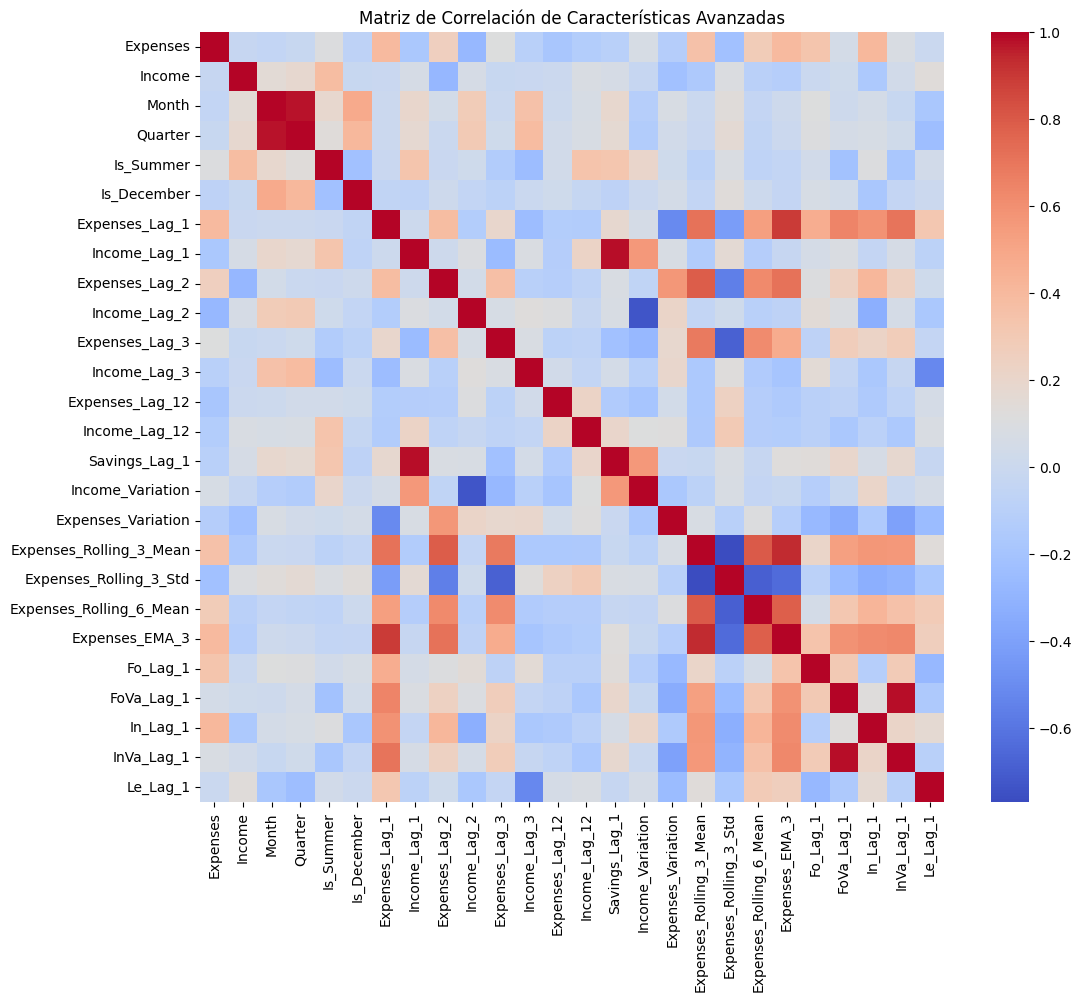

Correlaciones principales con Expenses:
Expenses                   1.000000
In_Lag_1                   0.409822
Expenses_EMA_3             0.398788
Expenses_Lag_1             0.394610
Expenses_Rolling_3_Mean    0.352145
Fo_Lag_1                   0.330667
Expenses_Rolling_6_Mean    0.285033
Expenses_Lag_2             0.254812
Expenses_Lag_3             0.113719
Is_Summer                  0.107325
InVa_Lag_1                 0.086837
Income_Variation           0.072096
FoVa_Lag_1                 0.047178
Le_Lag_1                  -0.007154
Quarter                   -0.016406
Income                    -0.022935
Month                     -0.049032
Is_December               -0.076213
Income_Lag_3              -0.099022
Savings_Lag_1             -0.104182
Expenses_Variation        -0.120809
Income_Lag_12             -0.132457
Income_Lag_1              -0.173756
Expenses_Lag_12           -0.188074
Expenses_Rolling_3_Std    -0.218455
Income_Lag_2              -0.275443
Name: Expenses, dtype: f

In [82]:
plt.figure(figsize=(12, 10))
correlation = df_final.corr()
sns.heatmap(correlation, annot=False, cmap='coolwarm')
plt.title("Matriz de Correlación de Características Avanzadas")
plt.show()

# Correlación específica con el Target
target_corr = correlation['Expenses'].sort_values(ascending=False)
print("Correlaciones principales con Expenses:")
print(target_corr)

## 4. División y Exportación
Guardamos los datos listos para los modelos de ML en `data/processed`.

In [83]:
train_df, _, test_df = train_val_test_split(df_final, "db_clean_avanzado", test_size=0.2, val_size=0, verbose=True)
print("\nDatos exportados correctamente para entrenamiento.")

Train: 43, Val: 0, Test: 11

Datos exportados correctamente para entrenamiento.


In [84]:
# 6. Separar target
X, y = split_target(train_df)


# 1. ENTRENAR (Baseline y Avanzado)
model_lr = train_sklearn_model(X, y, model_type="lr")
model_rf = train_sklearn_model(X, y, model_type="rf")
model_xgb = train_sklearn_model(X, y, model_type="xgb")
model_hgb = train_sklearn_model(X, y, model_type="hgb")
model_arima = train_arima_model(y)

# Seleccionamos variables externas verdaderas que ayuden a predecir, descartando lags de Expenses
columnas_externas = ['Income_Lag_1', 'Is_Summer', 'Quarter', 'Savings_Lag_1', 'Is_December']
# Nos aseguramos de que existan por si acaso no generaste is_summer
cols_validas = [c for c in columnas_externas if c in X.columns]

# Para evitar un proceso extremadamente lento de SARIMAX por culpa de auto_arima con muchas variables,
# apagamos estacionalidad si hay demasiadas variaciones bruscas intermensuales o histórico muy corto.
model_sarimax = train_sarimax_model(X[cols_validas], y, seasonal=False, m=6, use_log=True)

model_lstm, (scaler_X, scaler_y) = train_lstm_model(X, y)

model_ensemble = train_voting_ensemble(estimators=[
    ("hgb", model_hgb),
    ("xgb", model_xgb)
    ], X=X, y=y)

# 2. EVALUAR
_, test_df = load_train_test_data(filename="orig")
test_df = preprocess_data(test_df, verbose=False)
test_df = add_features(test_df, verbose=False)

# Eliminar cualquier NaN residual que haya quedado en el test (de importaciones antiguas si las hubiera)
test_df = test_df.dropna() 

X_test, y_test = split_target(test_df)

print("\n\n¡Datos listos para evaluar!\n\n")

res_lr = evaluate_predictions(y_test, model_lr.predict(X_test), "Linear Regression")
res_rf = evaluate_predictions(y_test, model_rf.predict(X_test), "Random Forest")
res_xgb = evaluate_predictions(y_test, model_xgb.predict(X_test), "XGBoost")
res_hgb = evaluate_predictions(y_test, model_hgb.predict(X_test), "HistGradientBoosting")
res_arima = evaluate_predictions(y_test, evaluate_arima(y_test, model_arima), "ARIMA")
res_sarimax = evaluate_predictions(y_test, evaluate_sarimax_wfv(X[cols_validas], y, X_test[cols_validas], y_test, model_sarimax, use_log=True), "SARIMAX")

y_test_aligned_lstm, y_pred_lstm = evaluate_lstm(X_test, y_test, model_lstm, scaler_X, scaler_y, time_steps=3)
res_lstm = evaluate_predictions(y_test_aligned_lstm, y_pred_lstm, "LSTM")

res_ensemble = evaluate_predictions(y_test, model_ensemble.predict(X_test), "Ensemble")

print(pd.DataFrame([res_lr, res_rf, res_xgb, res_hgb, res_arima, res_sarimax, res_lstm, res_ensemble]))





¡Datos listos para evaluar!


                  Model       MAE      RMSE      R2
0     Linear Regression   75.7305  107.1071 -0.3655
1         Random Forest   70.4877  118.3252 -0.6665
2               XGBoost   69.6487   90.7691  0.0193
3  HistGradientBoosting   78.1054   90.5898  0.0232
4                 ARIMA   74.2911   93.3286 -0.0367
5               SARIMAX  178.8721  260.4498 -7.0741
6                  LSTM   75.8249  103.8451 -0.0883
7              Ensemble   72.9447   85.2435  0.1351
